In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
data = pd.read_csv("../data/get_around_pricing_project.csv")
data.head(20)

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183
5,5,Citroën,152352,225,petrol,black,convertible,True,True,False,False,True,True,True,131
6,6,Citroën,205219,145,diesel,grey,convertible,True,True,False,False,True,True,True,111
7,7,Citroën,115560,105,petrol,white,convertible,True,True,False,False,False,True,True,78
8,8,Peugeot,123886,125,petrol,black,convertible,True,False,False,False,False,True,True,79
9,9,Citroën,139541,135,diesel,white,convertible,False,False,False,False,True,False,True,132


In [3]:
data.shape

(4843, 15)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 4843 non-null   int64 
 1   model_key                  4843 non-null   object
 2   mileage                    4843 non-null   int64 
 3   engine_power               4843 non-null   int64 
 4   fuel                       4843 non-null   object
 5   paint_color                4843 non-null   object
 6   car_type                   4843 non-null   object
 7   private_parking_available  4843 non-null   bool  
 8   has_gps                    4843 non-null   bool  
 9   has_air_conditioning       4843 non-null   bool  
 10  automatic_car              4843 non-null   bool  
 11  has_getaround_connect      4843 non-null   bool  
 12  has_speed_regulator        4843 non-null   bool  
 13  winter_tires               4843 non-null   bool  
 14  rental_p

In [5]:
data.describe()

,Unnamed: 0,mileage,engine_power,rental_price_per_day
count,4843.000000,4.843000e+03,4843.00000,4843.000000
mean,2421.000000,1.409628e+05,128.98823,121.214536
std,1398.198007,6.019674e+04,38.99336,33.568268
min,0.000000,-6.400000e+01,0.00000,10.000000
25%,1210.500000,1.029135e+05,100.00000,104.000000
50%,2421.000000,1.410800e+05,120.00000,119.000000
75%,3631.500000,1.751955e+05,135.00000,136.000000
max,4842.000000,1.000376e+06,423.00000,422.000000


In [6]:
data.groupby("has_air_conditioning")["rental_price_per_day"].mean()


has_air_conditioning
False    117.071410
True     137.587935
Name: rental_price_per_day, dtype: float64

In [7]:
data.groupby("has_gps")["rental_price_per_day"].mean()

has_gps
False    100.809761
True     126.550925
Name: rental_price_per_day, dtype: float64

In [8]:
data.groupby("paint_color")["rental_price_per_day"].mean()

paint_color
beige     123.975610
black     122.780159
blue      117.660563
brown     121.219941
green      77.555556
grey      120.247660
orange    135.666667
red       122.923077
silver    116.112462
white     127.304833
Name: rental_price_per_day, dtype: float64

In [9]:
data['paint_color'].value_counts()

paint_color
black     1633
grey      1175
blue       710
white      538
brown      341
silver     329
red         52
beige       41
green       18
orange       6
Name: count, dtype: int64

In [10]:
data['car_type'].value_counts()

car_type
estate         1606
sedan          1168
suv            1058
hatchback       699
subcompact      117
coupe           104
convertible      47
van              44
Name: count, dtype: int64

In [11]:
data.groupby("car_type")["rental_price_per_day"].mean()

car_type
convertible    123.382979
coupe          142.788462
estate         111.497509
hatchback      112.098712
sedan          122.698630
subcompact      94.820513
suv            141.251418
van            116.386364
Name: rental_price_per_day, dtype: float64

In [12]:
data.groupby("fuel")["rental_price_per_day"].mean()

fuel
diesel           121.548373
electro          145.000000
hybrid_petrol    184.750000
petrol           110.068063
Name: rental_price_per_day, dtype: float64

In [13]:
#CLEAN DATASET TO ML
data_fuel = data['fuel'].value_counts()
data['fuel'] = data['fuel'].apply(lambda x: x if data_fuel[x] > 30 else "other")
data_fuel_count = data['fuel'].value_counts().reset_index()
data_fuel_count

,fuel,count
0,diesel,4641
1,petrol,191
2,other,11


In [14]:
fig = px.bar(
    data_fuel_count,
    x="fuel",
    y="count", 
    color="fuel",
    text="count"
)

fig.show()

In [15]:
data_colors = data['paint_color'].value_counts()
data['paint_color'] = data['paint_color'].apply(lambda x: x if data_colors[x] > 50 else "other")
data_colors_count = data['paint_color'].value_counts().reset_index()
data_colors_count

,paint_color,count
0,black,1633
1,grey,1175
2,blue,710
3,white,538
4,brown,341
5,silver,329
6,other,65
7,red,52


In [16]:
fig = px.bar(
    data_colors_count,
    x="paint_color",
    y="count", 
    color="paint_color",
    text="count"
)

fig.show()

In [17]:
#CLEAN DATASET TO ML
data_model = data['model_key'].value_counts()
data['model_key'] = data['model_key'].apply(lambda x: x if data_model[x] > 30 else "other")

In [18]:
data_model_chart = data['model_key'].value_counts().reset_index()
data_model_chart

,model_key,count
0,Citroën,969
1,Renault,916
2,BMW,827
3,Peugeot,642
4,Audi,526
5,Nissan,275
6,Mitsubishi,231
7,Mercedes,97
8,Volkswagen,65
9,other,53


In [19]:
fig = px.bar(
    data_model_chart,
    x="model_key",
    y="count", 
    color="model_key",
    text="count"
)

fig.show()

In [20]:
data_car_type = data['car_type'].value_counts().reset_index()
data_car_type

,car_type,count
0,estate,1606
1,sedan,1168
2,suv,1058
3,hatchback,699
4,subcompact,117
5,coupe,104
6,convertible,47
7,van,44


In [21]:
fig = px.bar(
    data_car_type,
    x="car_type",
    y="count", 
    color="car_type",
    text="count"
)

fig.show()

In [22]:
bool_cols = [
    "private_parking_available", 
    "has_gps", 
    "has_air_conditioning", 
    "automatic_car", 
    "has_getaround_connect", 
    "has_speed_regulator", 
    "winter_tires"
]

# 2. Compter True / False pour chaque colonne
counts = pd.DataFrame({col: data[col].value_counts() for col in bool_cols}).T
counts = counts.fillna(0).astype(int)  # Nettoyage

# 3. Transformer en format long
counts = counts.reset_index().melt(id_vars="index", var_name="value", value_name="count")
counts.rename(columns={"index": "feature"}, inplace=True)

# 4. Bar chart empilé
fig = px.bar(
    counts,
    x="feature",
    y="count",
    color="value",
    barmode="relative",  # "relative" = proportion (100%)
    text="count",
    title="Répartition True/False des variables booléennes"
)
fig.show()


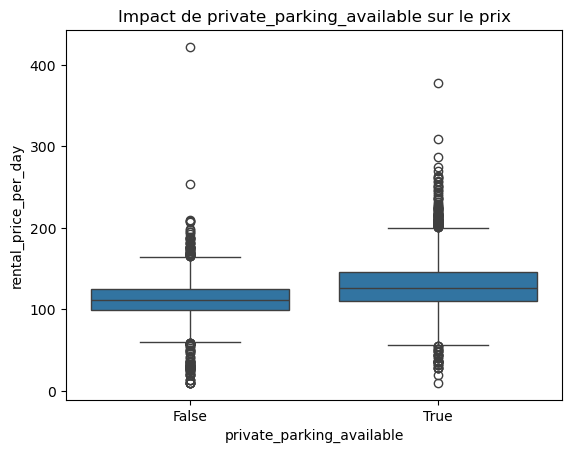

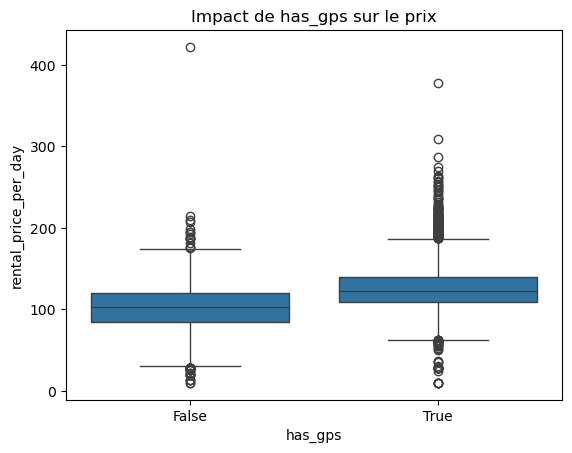

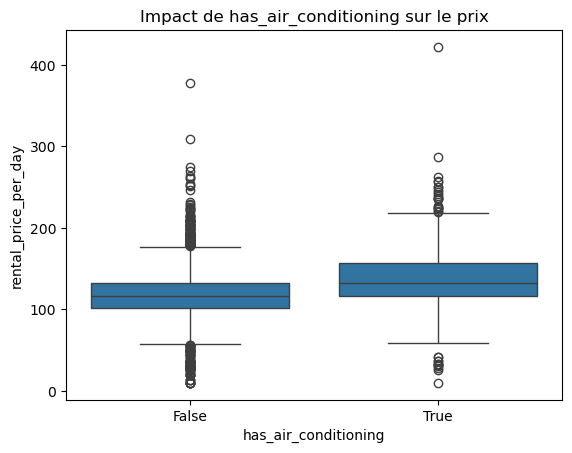

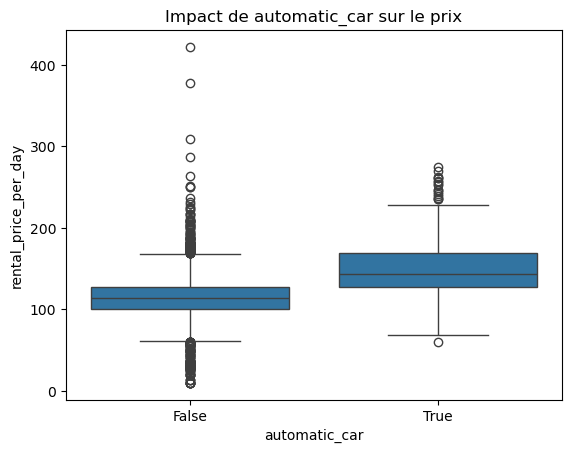

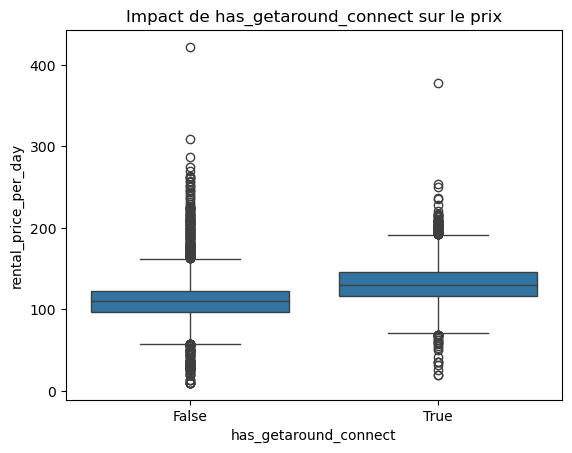

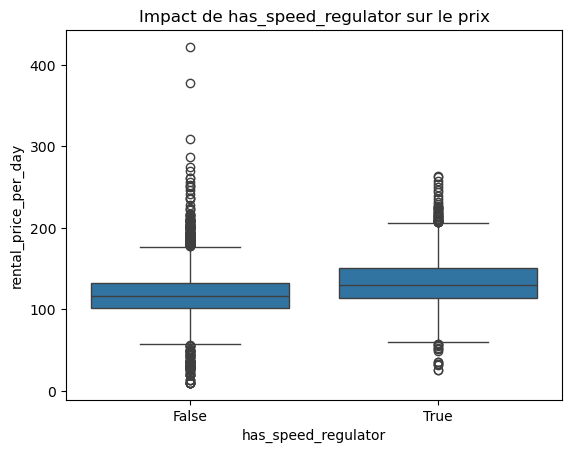

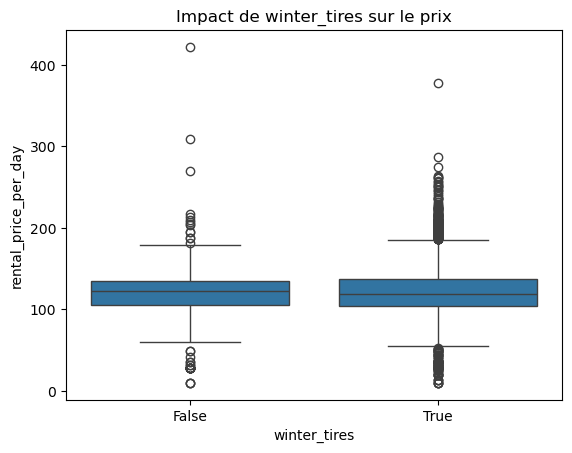

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in bool_cols:
    sns.boxplot(x=data[col], y=data["rental_price_per_day"])
    plt.title(f"Impact de {col} sur le prix")
    plt.show()

In [24]:
for col in bool_cols:
    print(f"\n--- {col} ---")
    print(data.groupby(col)["rental_price_per_day"].mean())


--- private_parking_available ---
private_parking_available
False    110.781293
True     129.762585
Name: rental_price_per_day, dtype: float64

--- has_gps ---
has_gps
False    100.809761
True     126.550925
Name: rental_price_per_day, dtype: float64

--- has_air_conditioning ---
has_air_conditioning
False    117.071410
True     137.587935
Name: rental_price_per_day, dtype: float64

--- automatic_car ---
automatic_car
False    114.199948
True     149.513514
Name: rental_price_per_day, dtype: float64

--- has_getaround_connect ---
has_getaround_connect
False    111.339074
True     132.786099
Name: rental_price_per_day, dtype: float64

--- has_speed_regulator ---
has_speed_regulator
False    116.906369
True     134.754491
Name: rental_price_per_day, dtype: float64

--- winter_tires ---
winter_tires
False    118.942249
True     121.380151
Name: rental_price_per_day, dtype: float64


In [25]:
from scipy.stats import ttest_ind

for col in bool_cols:
    group_true = data[data[col] == True]["rental_price_per_day"]
    group_false = data[data[col] == False]["rental_price_per_day"]

    stat, pval = ttest_ind(group_true, group_false, equal_var=False)

    print(f"{col} : p-value = {pval:.4f}")

private_parking_available : p-value = 0.0000
has_gps : p-value = 0.0000
has_air_conditioning : p-value = 0.0000
automatic_car : p-value = 0.0000
has_getaround_connect : p-value = 0.0000
has_speed_regulator : p-value = 0.0000
winter_tires : p-value = 0.3161


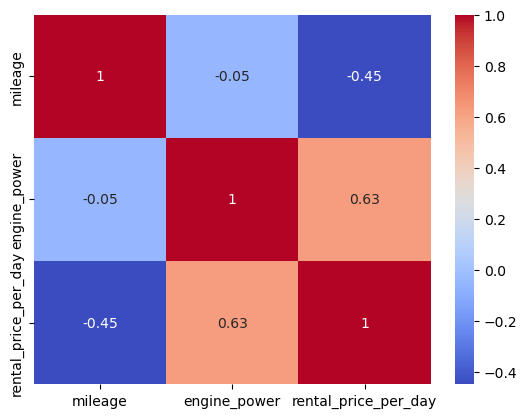

In [26]:
sns.heatmap(data[["mileage","engine_power","rental_price_per_day"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [27]:
fig = px.histogram(
    data,
    x="rental_price_per_day"
)
fig.show()

In [28]:
fig = px.histogram(
    data,
    x="mileage"
)
fig.show()

In [29]:
fig = px.histogram(
    data,
    x="engine_power"
)
fig.show()

# Nettoyage de données à exploiter

In [30]:
df = pd.read_csv("../data/get_around_pricing_project.csv")
df.head()

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [31]:
model_count = df['model_key'].value_counts()
df['model_key'] = df['model_key'].apply(lambda x: x if model_count[x] > 30 else "other")
fuel_count = df['fuel'].value_counts()
df['fuel'] = df['fuel'].apply(lambda x: x if fuel_count[x] > 30 else "other")
color_count = df['paint_color'].value_counts()
df['paint_color'] = df['paint_color'].apply(lambda x: x if color_count[x] > 50 else "other")
df = df[df["mileage"] <= 500_000]
df = df.drop(columns=["winter_tires", "Unnamed: 0"])
df.head()

,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,183
